In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np


In [2]:
df = pd.read_csv("/kaggle/input/datasets/prem043m/weatheraus-rainfall-prediction-dataset-cleaned-csv/weatherAUS_rainfall_prediction_dataset_cleaned.csv")


In [3]:
df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


In [4]:
# no null in dataset 
df.tail(4)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145456,2012-01-15,Woomera,17.0,33.5,0.0,12.40,12.70,SSE,43.0,ESE,...,38.0,12.0,1015.2,1011.8,0.0,0.0,22.2,32.0,No,No
145457,2012-01-16,Woomera,18.9,38.8,0.0,12.00,12.40,N,41.0,ENE,...,10.0,5.0,1012.0,1008.7,0.0,0.0,27.6,37.9,No,No
145458,2012-01-18,Woomera,23.5,38.3,0.0,18.20,13.00,SSE,50.0,SSE,...,54.0,22.0,1013.2,1011.3,1.0,1.0,25.1,35.4,No,No
145459,2017-01-10,Woomera,21.7,34.5,0.0,5.47,7.61,SE,37.0,SSE,...,71.0,36.0,1010.5,1008.8,6.0,2.0,24.0,33.5,No,No


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [6]:
df.describe()


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,14.043384,18.662601,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,8.861059,8.716581,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,13.000000,18.660000,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [7]:
int(df.duplicated().sum())


0

In [8]:
df.columns


Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

/tmp/ipykernel_17/858449777.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'RainTomorrow', data = df , palette = "Blues")


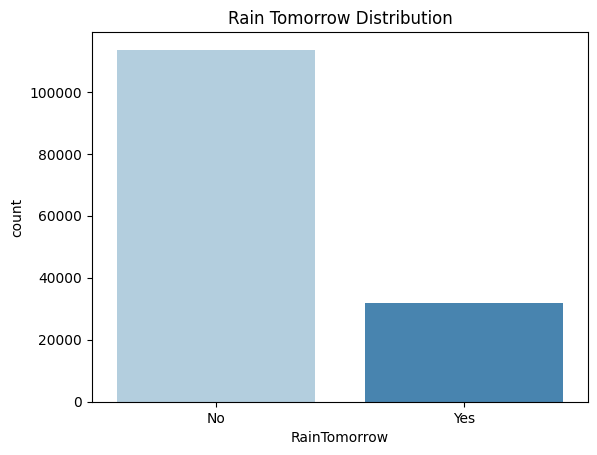

In [9]:
sns.countplot(x = 'RainTomorrow', data = df , palette = "Blues")
plt.title("Rain Tomorrow Distribution")
plt.show()


In [10]:
df['year'] = pd.to_datetime(df['Date']).dt.year


In [11]:
rain_per_year = df.groupby('year')['RainTomorrow'].value_counts(normalize=True).unstack()


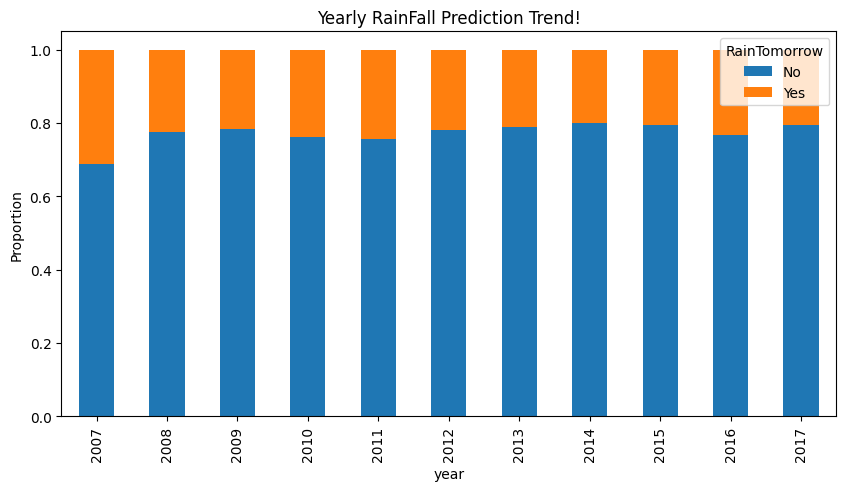

In [12]:
rain_per_year.plot(kind = "bar",stacked=True, figsize=(10,5))
plt.title("Yearly RainFall Prediction Trend!")
plt.ylabel("Proportion")
plt.show()


In [13]:
rain_per_location = df.groupby("Location")["RainTomorrow"].value_counts().unstack()


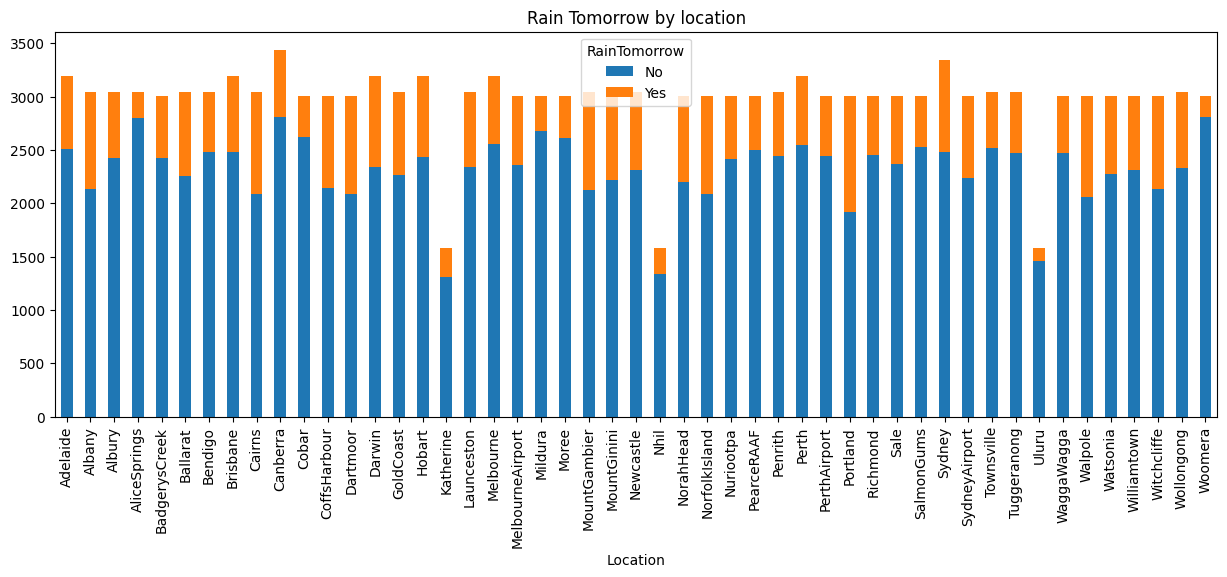

In [14]:
rain_per_location.plot(kind= "bar", stacked=True, figsize=(15,5))
plt.title("Rain Tomorrow by location")
plt.show()


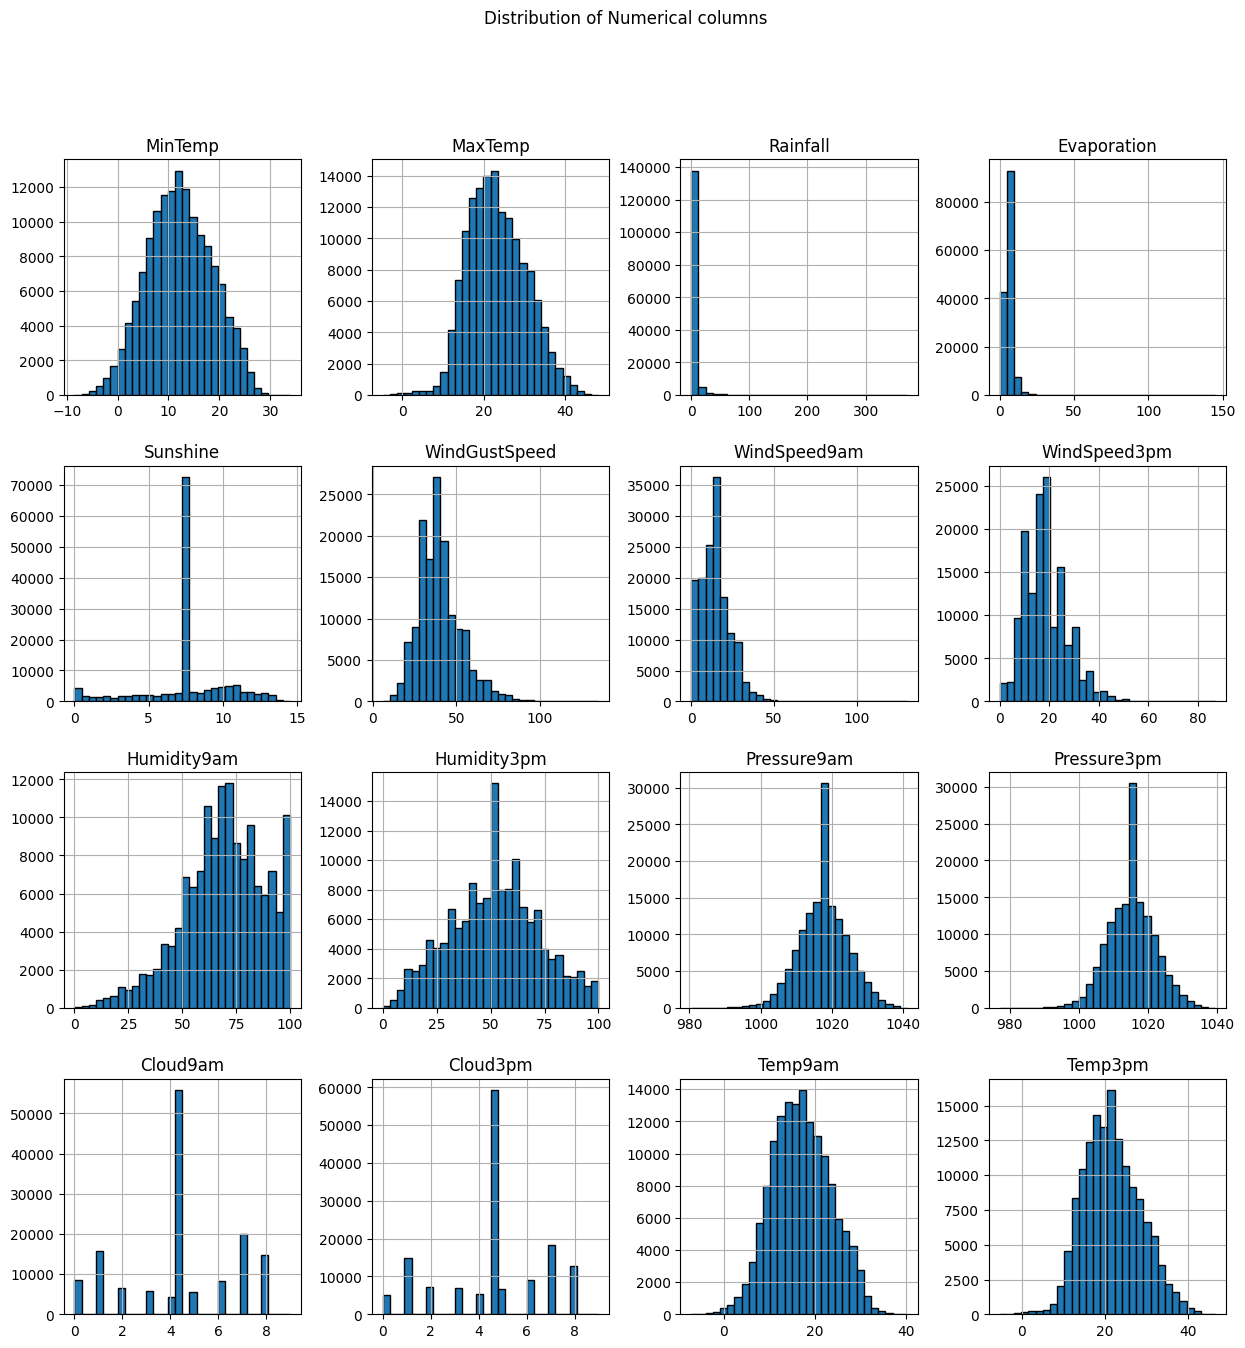

In [15]:
numcols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustSpeed','WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm']

df[numcols].hist(figsize=(15,15),bins = 30 , edgecolor = "black")
plt.suptitle("Distribution of Numerical columns")
plt.show()


<Axes: xlabel='WindGustDir', ylabel='count'>

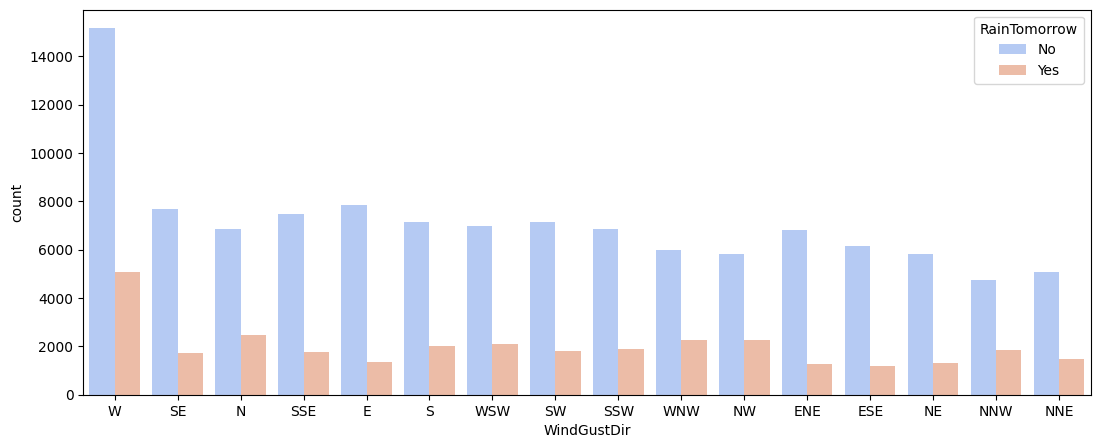

In [16]:
plt.figure(figsize=(13,5))
sns.countplot(x = "WindGustDir",hue = "RainTomorrow", data = df, order=df['WindGustDir'].value_counts().index,palette="coolwarm")


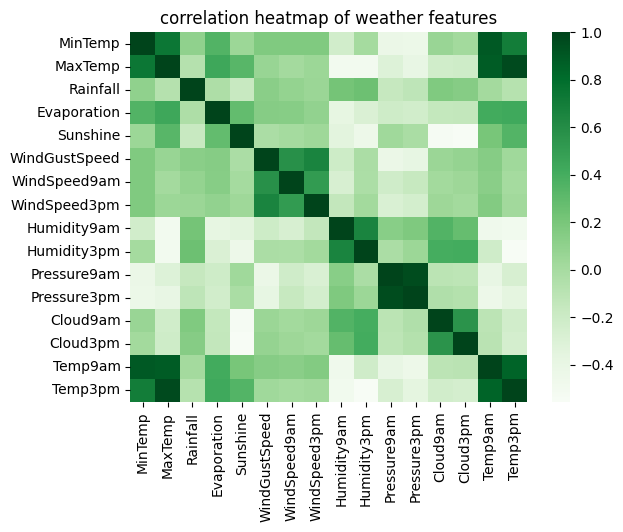

In [17]:
plt.Figure(figsize=(16,8))
corr = df[numcols].corr()
sns.heatmap(corr, annot=False, fmt = ".2f", cmap="Greens")
plt.title('correlation heatmap of weather features')
plt.show()


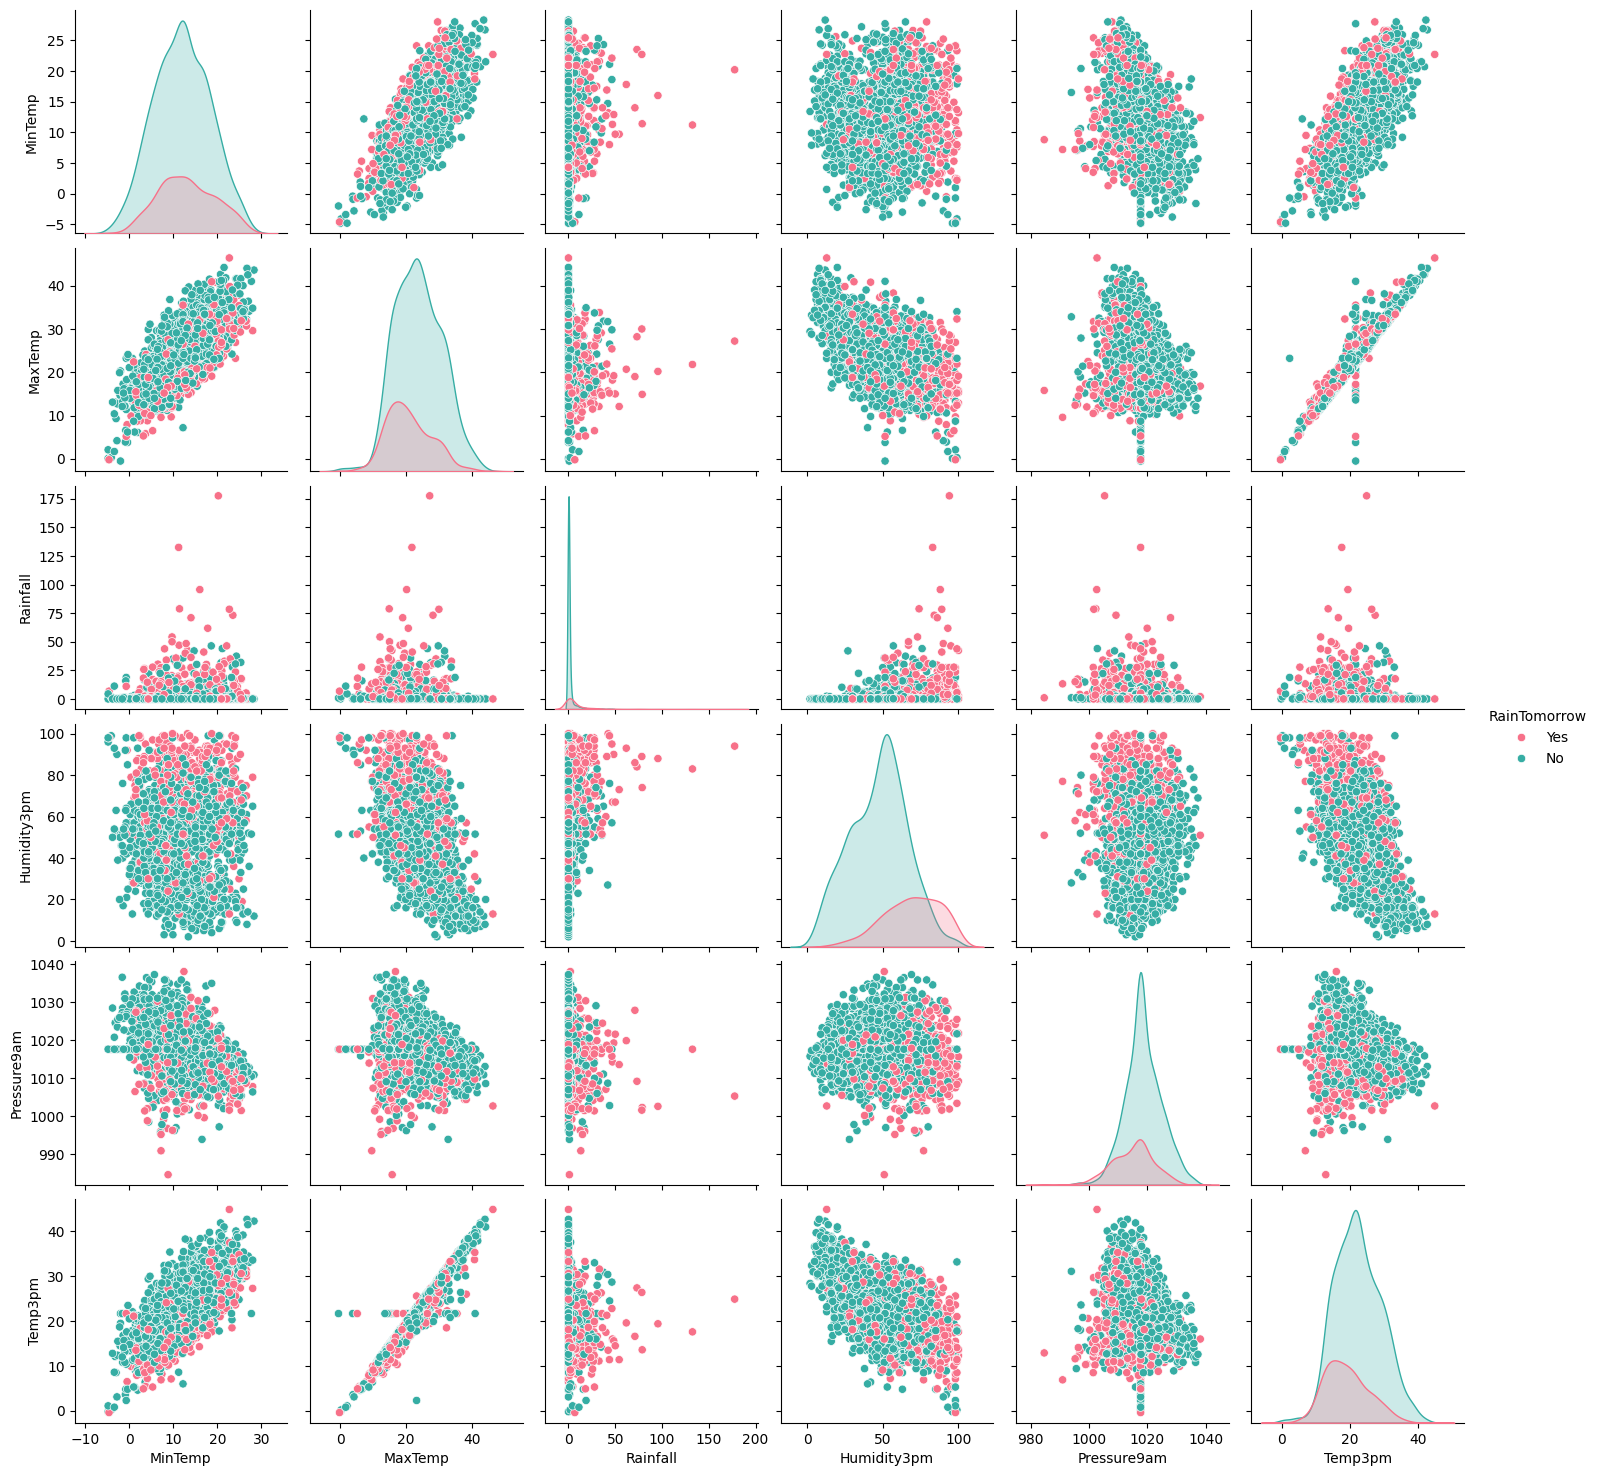

In [18]:
sample_df = df.sample(2000,random_state=42)
sns.pairplot(sample_df[['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm','Pressure9am','Temp3pm',"RainTomorrow"]],hue = "RainTomorrow", palette = "husl")
plt.show()


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [21]:
xgb_available = False
try:
    from xgboost import XGBClassigier
    xgb_available = True
except Exception:
    pass


In [22]:
target = "RainTomorrow"

df = df.dropna(subset=[target]).copy()


In [23]:
if "Date" in df.columns:
    df.drop(columns=['Date'],inplace=True)


In [24]:
if df[target].dtype == object:
    df[target] = df[target].str.strip().str.title()
    df[target] = (df[target] == "Yes").astype(int)
df


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year
0,Adelaide,10.8,21.2,0.0,1.80,6.60,ENE,22.0,ENE,NW,...,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,0,2010
1,Adelaide,3.7,19.0,0.0,1.40,7.61,N,24.0,N,NNE,...,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,0,2014
2,Adelaide,9.6,15.8,0.0,2.60,7.61,NE,52.0,NNE,NE,...,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,1,2014
3,Adelaide,10.1,15.5,16.6,0.80,7.61,NNE,50.0,NW,NW,...,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,1,2014
4,Adelaide,11.2,16.2,1.8,0.60,7.61,NW,30.0,WNW,WNW,...,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,1,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Woomera,16.8,31.9,0.0,27.00,7.61,SSE,44.0,SE,S,...,17.0,1017.3,1014.2,0.00,4.51,20.2,29.5,No,0,2012
145456,Woomera,17.0,33.5,0.0,12.40,12.70,SSE,43.0,ESE,ESE,...,12.0,1015.2,1011.8,0.00,0.00,22.2,32.0,No,0,2012
145457,Woomera,18.9,38.8,0.0,12.00,12.40,N,41.0,ENE,NNW,...,5.0,1012.0,1008.7,0.00,0.00,27.6,37.9,No,0,2012
145458,Woomera,23.5,38.3,0.0,18.20,13.00,SSE,50.0,SSE,E,...,22.0,1013.2,1011.3,1.00,1.00,25.1,35.4,No,0,2012


In [25]:
X = df.drop(columns=[target])
Y = df[target].values


In [26]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()


In [27]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.20,random_state=42,stratify=Y)


In [28]:
X_train


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,year
108457,SalmonGums,8.2,17.0,0.00,5.47,7.61,SSW,44.0,SW,SSW,...,82.0,65.0,1017.65,1015.26,4.45,4.51,12.1,15.7,No,2009
106148,Sale,7.6,16.7,0.00,5.47,7.61,WNW,63.0,W,W,...,51.0,39.0,1011.20,1011.50,4.00,1.00,10.9,15.8,No,2016
55507,Melbourne,6.7,13.0,5.40,2.00,6.10,SSW,31.0,WSW,SW,...,81.0,71.0,1033.50,1033.10,2.00,6.00,8.0,12.2,Yes,2017
7096,Albury,13.4,35.4,0.00,5.47,7.61,W,46.0,SSE,SSW,...,55.0,25.0,1015.60,1011.20,4.45,4.51,21.7,32.6,No,2009
9926,AliceSprings,1.2,21.0,0.00,5.47,7.61,E,44.0,W,ESE,...,63.0,30.0,1026.60,1023.20,4.45,4.51,10.2,19.8,No,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,Adelaide,16.2,23.1,2.36,5.47,6.40,SSE,48.0,SW,SSW,...,58.0,61.0,1013.50,1014.50,4.45,4.51,20.0,18.4,No,2013
123581,Uluru,23.3,42.7,0.00,5.47,7.61,WSW,44.0,SSE,N,...,15.0,6.0,1010.60,1006.30,4.45,4.51,33.8,41.0,No,2013
58461,MelbourneAirport,14.2,21.7,0.00,4.40,8.40,SE,33.0,W,SE,...,81.0,54.0,1025.00,1023.50,7.00,2.00,16.1,20.6,No,2010
84651,Nuriootpa,13.4,30.1,0.00,7.20,12.20,SE,43.0,ESE,ENE,...,68.0,23.0,1016.60,1014.60,0.00,2.00,17.9,28.1,No,2012


In [29]:
X_test


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,year
111453,Sydney,11.2,20.3,0.0,6.20,10.60,W,46.00,W,WSW,...,48.00,30.00,1018.40,1017.00,1.00,1.00,14.00,19.60,No,2016
69989,MountGinini,3.3,12.8,0.0,5.47,7.61,SW,54.00,NNW,NW,...,68.88,72.00,1017.65,1015.26,4.45,4.51,16.99,11.50,No,2012
81527,NorfolkIsland,22.1,24.8,0.0,5.80,1.50,E,85.00,ESE,ESE,...,78.00,79.00,1012.30,1007.50,7.00,8.00,23.00,23.00,No,2016
87060,PearceRAAF,14.9,35.4,0.0,5.47,10.80,W,37.00,NNW,W,...,48.00,27.00,1012.40,1010.50,0.00,0.00,21.60,33.30,No,2009
39209,Dartmoor,18.1,19.4,6.8,2.80,0.60,SW,41.00,SW,SSW,...,99.00,94.00,1011.10,1013.70,4.45,4.51,18.70,17.80,Yes,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65055,Moree,17.1,28.9,0.0,8.40,10.30,ENE,48.00,E,ENE,...,53.00,32.00,1022.80,1020.20,6.00,7.00,21.10,28.40,No,2010
8860,Albury,9.1,16.2,16.6,5.47,7.61,N,44.00,N,N,...,82.00,52.00,1009.30,1007.90,8.00,1.00,12.80,15.70,Yes,2016
1167,Adelaide,19.0,35.4,0.0,5.47,7.61,W,40.04,NNE,WNW,...,40.00,22.00,1011.50,1008.00,4.45,4.51,26.20,33.50,No,2017
36402,CoffsHarbour,17.3,24.3,63.8,2.00,0.50,ESE,48.00,SW,ESE,...,75.00,54.00,1023.90,1023.50,7.00,7.00,18.40,21.60,Yes,2011


In [30]:
Y_train


array([0, 0, 0, ..., 0, 0, 1])

In [31]:
Y_test


array([0, 0, 1, ..., 0, 1, 0])

In [32]:
numeric_imputer=SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()


In [33]:
categorical_encoder = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
])


In [34]:
categorical_encoder


Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1))])

In [35]:
prepocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer,numeric_cols),
        ("cat",categorical_encoder,categorical_cols)
    ],
    remainder="drop"
)


In [36]:
prepocessor_unscaled


ColumnTransformer(transformers=[('num', SimpleImputer(strategy='median'),
                                 ['MinTemp', 'MaxTemp', 'Rainfall',
                                  'Evaporation', 'Sunshine', 'WindGustSpeed',
                                  'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
                                  'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                                  'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
                                  'year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Location', 'WindGustDir', 'WindDir9am',
                                  'WindDir3pm', 'RainToday'])])

In [37]:
prepocessor_scaled = ColumnTransformer(
    transformers=[
        ("num",Pipeline(
            [
                ("imputer",numeric_imputer),
                ("scaler",numeric_scaler)
            ]),numeric_cols
        ),
        ("cat",categorical_encoder,categorical_cols)
    ],
    remainder="drop"
)


In [38]:
prepocessor_scaled


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MinTemp', 'MaxTemp', 'Rainfall',
                                  'Evaporation', 'Sunshine', 'WindGustSpeed',
                                  'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
                                  'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                                  'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
                                  'year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Location', 'WindGustDir', 'WindDir9am',
                                  'WindDir3pm', 'RainToday'])])

In [39]:
models = {
    "Logistic Regression":Pipeline(
        [
            ("prep",prepocessor_scaled),
            ("clf",LogisticRegression(max_iter=1000,n_jobs=None))
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("prep",prepocessor_unscaled),
            ("clf",DecisionTreeClassifier(random_state=42))
        ]
    ),
    "Random Forest":Pipeline(
        [
            ("prep",prepocessor_unscaled),
            ("clf",RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1))
        ]
    ),
    "Naive Bayes (Guasiian)":Pipeline(
        [
            ("prep",prepocessor_unscaled),
            ("clf",GaussianNB())
        ]
    ),
    "KNN (k=11)":Pipeline(
        [
            ("prep",prepocessor_scaled),
            ("clf",KNeighborsClassifier(n_neighbors=11))
        ]
    ),
}


In [40]:
if xgb_available:
    models["XGBoost"] = Pipeline(
        ("prep",prepocessor_unscaled),
        ("clf",XGBClassigier(
            n_estimators = 400,
            max_depth = 6,
            learning_rate = 0.05,
            subsample = 0.9,
            colsample_bytree = 0.9,
            reg_lambda = 1.0,
            random_state = 42,
            eval_metric = "logloss",
            tree_method = "hist",
        ))
    )


In [41]:
accuarcies = {}

for name,pipe in models.items():
    pipe.fit(X_train,Y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(Y_test,y_pred)*100
    accuarcies[name] = acc
    print(f"{name}: {acc:.2f}% Accuracy")


Logistic Regression: 83.96% Accuracy
Decision Tree: 78.23% Accuracy
Random Forest: 85.63% Accuracy
Naive Bayes (Guasiian): 80.06% Accuracy
KNN (k=11): 83.28% Accuracy


In [42]:
print("\n=== Accuracies (Descending) ===")
for name ,acc  in sorted(accuarcies.items(),key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.2f}%")
plt.Figure(figsize=(10,5))
names = list(accuarcies.keys())
vals = [accuarcies[k] for k in names]

order = np.argsort(vals)[::-1]
names_sorted = [names[i] for i in order]
vals_sorted = [vals[i] for i in order]



=== Accuracies (Descending) ===
Random Forest: 85.63%
Logistic Regression: 83.96%
KNN (k=11): 83.28%
Naive Bayes (Guasiian): 80.06%
Decision Tree: 78.23%


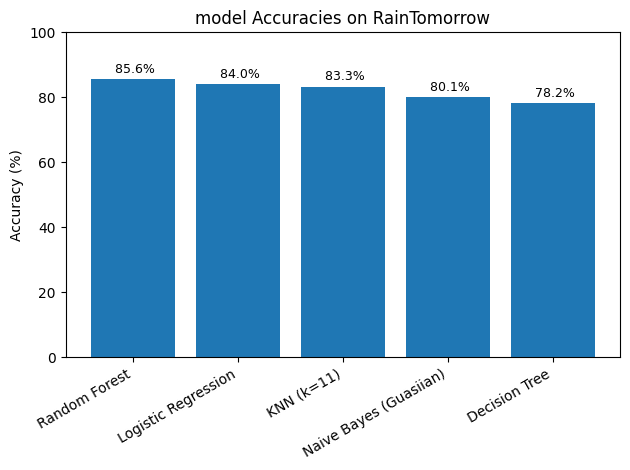

In [43]:
plt.bar(names_sorted,vals_sorted)
plt.ylabel("Accuracy (%)")
plt.title("model Accuracies on RainTomorrow")
plt.xticks(rotation = 30,ha = "right")
plt.ylim(0,100)
for i , v in  enumerate(vals_sorted):
    plt.text(i, v+1, f"{v: .1f}%", ha = "center", va = "bottom", fontsize = 9)
plt.tight_layout()
plt.show()



In [44]:
X_train.columns.tolist()


['Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'year']

In [45]:
feature_cols = ['Location','MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine',
                'WindGustDir','WindGustSpeed','WindDir9am','WindDir3pm',
                'WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm',
                'Pressure9am','Pressure3pm','Cloud9am','Cloud3pm',
                'Temp9am','Temp3pm','RainToday','year']

def make_input(data_dict):
    new_df = pd.DataFrame(data_dict,index=[0])
    for col in feature_cols:
        if col not in new_df.columns:
            new_df[col] = np.nan
    
    return new_df[feature_cols]


In [46]:
sample_data = {
    "Location": "Sydney",
    "MinTemp": 15.5,
    "MaxTemp": 26.5,
    "Rainfall": 0.0,
    "Evaporation": 6.0,
    "Sunshine": 7.5,
    "WindGustDir": "NW",
    "WindGustSpeed": 60,
    "WindDir9am": "SW",
    "WindDir3pm": "W",
    "WindSpeed9am": 15,
    "WindSpeed3pm": 40,
    "Humidity9am": 75,
    "Humidity3pm": 45,
    "Pressure9am": 1005.6,
    "Pressure3pm": 999.8,
    "Cloud9am": 5,
    "Cloud3pm": 7,
    "Temp9am": 19.0,
    "Temp3pm": 25.0,
    "RainToday": "No",
    "year": 2024
}


In [47]:
new_data = make_input(sample_data)

prediction = models["Random Forest"].predict(new_data)[0]
print("Rain Tomorrow:", "Yes" if prediction==1 else "No")


Rain Tomorrow: No


In [48]:
proba = models["Random Forest"].predict_proba(new_data)[0]
p_no, p_yes = proba
print(f"Probability of No Rain: {p_no*100:.2f}%")
print(f"Probability of Rain: {p_yes*100:.2f}%")


Probability of No Rain: 60.67%
Probability of Rain: 39.33%


In [49]:
# custom threshold for rain prediction
threshold = 0.7  # 60% cutoff

if p_yes >= threshold:
    prediction = "Yes"
else:
    prediction = "No"

print(f"Rain Tomorrow (with threshold {threshold*100:.0f}%): {prediction}")


Rain Tomorrow (with threshold 70%): No
